## CNN EuroSAT

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import os
from PIL import Image

In [2]:
import os
print(os.getcwd())                          # Dónde está parado Python
print(os.listdir('.'))                      # Qué hay en esa carpeta

c:\Users\faust\OneDrive - Universidad Torcuato Di Tella\Documents\LTD - Ditella\7° Cuatri\TD6\TP3-TD6
['.venv', 'best_model.pth', 'best_model_tl.pth', 'EuroSAT', 'EuroSATallBands', 'EuroSAT_CNN.ipynb', 'gradient_flow.png', 'label_map.json', 'latent_space.png', 'test.csv', 'train.csv', 'training_curves.png', 'validation.csv']


### Transformaciones

In [4]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

### Datasets: Train, Validation, Test

Leemos los datos. Configuramos una clase para manejar el dataset.

In [5]:
df_train = pd.read_csv('train.csv')
df_val   = pd.read_csv('validation.csv')
df_test  = pd.read_csv('test.csv')


class EuroSATDataset(Dataset):
    def __init__(self, df, base_dir='EuroSAT', transform=None):
        self.df        = df
        self.base_dir  = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.base_dir, self.df.iloc[idx]['Filename'])  # ← lo usás acá
        label    = self.df.iloc[idx]['Label']
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

### Pipeline de datos y Data Augentation

Creamos los datasets separados y sus loaders.

In [7]:
batch_size = 32

train_dataset = EuroSATDataset(df_train, base_dir='EuroSAT', transform=train_transforms)
val_dataset   = EuroSATDataset(df_val,   base_dir='EuroSAT', transform=val_test_transforms)
test_dataset  = EuroSATDataset(df_test,  base_dir='EuroSAT', transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [8]:
print('Train set size:', len(train_dataset))
print('Validation set size:', len(val_dataset))
print('Test set size:', len(test_dataset))

Train set size: 18900
Validation set size: 5400
Test set size: 2700


Visualizamos las imágenes (Un batch).

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

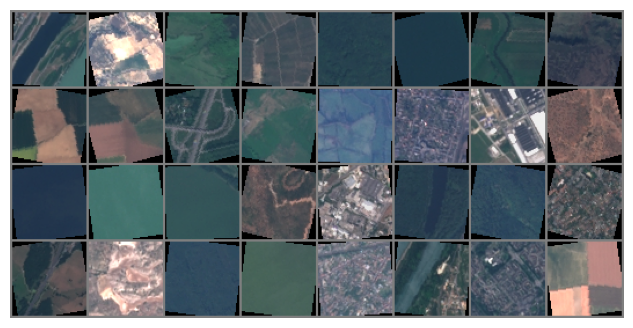

SeaLake         Residential     Highway         Residential     HerbaceousVegetation Forest          SeaLake         PermanentCrop   AnnualCrop      AnnualCrop      Industrial      Highway         Highway         River           Pasture         Residential     Forest          Forest          Forest          PermanentCrop   Pasture         SeaLake         HerbaceousVegetation River           Industrial      PermanentCrop   HerbaceousVegetation Forest          River           SeaLake         River           AnnualCrop     


In [10]:
#Muestro las imagenes, función de la práctica
label_names = {i: name for i, name in enumerate(df_train['ClassName'].unique())}

def imshow(img):
    img = img / 2 + 0.5          # Desnormalizamos
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))   # (C,H,W) → (H,W,C)
    npimg = np.clip(npimg, 0, 1)             # Evita warnings de clipping
    plt.figure(figsize=(16, 4))
    plt.imshow(npimg)
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{label_names[labels[j].item()]:15}' for j in range(batch_size)))

### Arquitectura CNN

In [11]:
class CNN_EuroSAT(torch.nn.Module):
    def __init__(self, n_features, size_hidden, n_outputs):
        super(CNN_EuroSAT, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=n_features, out_channels = size_hidden, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(size_hidden),
            nn.ReLU(),  # 64 x 64 x 3

            nn.Conv2d(in_channels = size_hidden, out_channels = size_hidden, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(size_hidden),
            nn.ReLU(),  # 64 x 64 x 64

            nn.MaxPool2d(kernel_size=2, stride=2)   # 32 x 32 x 64
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=size_hidden, out_channels=size_hidden*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(size_hidden*2),
            nn.ReLU(),  # 32 x 32 x 128

            nn.Conv2d(in_channels=size_hidden*2, out_channels=size_hidden*2, kernel_size= 3, padding = 1),
            nn.BatchNorm2d(size_hidden*2),
            nn.ReLU(),  # 32 x 32 x 128

            nn.MaxPool2d(kernel_size=2, stride=2)   # 16 x 16 x 128
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(size_hidden*2 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_outputs)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x
    
    def extract_features(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # Pasar por todo el fc excepto el último Linear
        x = self.fc[0](x)   # Flatten
        x = self.fc[1](x)   # Linear
        x = self.fc[2](x)   # ReLU
        # fc[3] es Dropout, fc[4] es el Linear final, no los pasamos
        return x             # output: (batch, 256)

### Loss Function, Optimizador

In [12]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN_EuroSAT(n_features=3, size_hidden=64, n_outputs=10)
model     = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

Métricas y monitoreo de gradientes

In [13]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

In [14]:
def get_grad_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms

primeras_epochs = 5      # Cuántas epocas monitorear
grad_history   = []

### Loop de Entrenamiento

In [15]:
n_epochs     = 20
best_val_acc = 0
train_losses = []
val_losses   = []

for epoch in range(n_epochs):

    # ── ENTRENAMIENTO ──
    model.train()
    train_loss = 0
    correct_train = 0
    total_train   = 0
    epoch_grads   = {}

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        if epoch < primeras_epochs and batch_idx == 0:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    norm = param.grad.norm().item()
                    if name not in epoch_grads:
                        epoch_grads[name] = []
                    epoch_grads[name].append(norm)

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)          #
        correct_train += (predicted == labels).sum().item()  #
        total_train   += labels.size(0)

    if epoch < primeras_epochs:
        grad_history.append(epoch_grads)

    # ── VALIDACIÓN ──
    model.eval()
    val_loss = 0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    # GUARDAR MÉTRICAS
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accs.append(100*correct_train/total_train)
    val_accs.append(100*correct/total)

    # guardar losses
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    val_acc        = 100 * correct / total

    # guardar mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  → Mejor modelo guardado: {val_acc:.2f}%')

    # scheduler con val loss
    scheduler.step(avg_val_loss)

    print(f'Epoch {epoch+1}/{n_epochs} '
          f'| Train Loss: {avg_train_loss:.4f} '
          f'| Val Loss: {avg_val_loss:.4f} '
          f'| Val Accuracy: {val_acc:.2f}%')


  → Mejor modelo guardado: 50.61%
Epoch 1/20 | Train Loss: 1.9111 | Val Loss: 1.3305 | Val Accuracy: 50.61%
  → Mejor modelo guardado: 57.94%
Epoch 2/20 | Train Loss: 1.4918 | Val Loss: 1.1529 | Val Accuracy: 57.94%
Epoch 3/20 | Train Loss: 1.3837 | Val Loss: 1.1404 | Val Accuracy: 55.15%
  → Mejor modelo guardado: 61.69%
Epoch 4/20 | Train Loss: 1.2746 | Val Loss: 1.0686 | Val Accuracy: 61.69%
  → Mejor modelo guardado: 75.06%
Epoch 5/20 | Train Loss: 1.1782 | Val Loss: 0.7889 | Val Accuracy: 75.06%
  → Mejor modelo guardado: 76.02%
Epoch 6/20 | Train Loss: 1.0905 | Val Loss: 0.7128 | Val Accuracy: 76.02%
  → Mejor modelo guardado: 82.02%
Epoch 7/20 | Train Loss: 0.9988 | Val Loss: 0.5560 | Val Accuracy: 82.02%
Epoch 8/20 | Train Loss: 0.9083 | Val Loss: 3.3658 | Val Accuracy: 60.37%
  → Mejor modelo guardado: 84.87%
Epoch 9/20 | Train Loss: 0.8549 | Val Loss: 0.4831 | Val Accuracy: 84.87%
Epoch 10/20 | Train Loss: 0.7953 | Val Loss: 0.4638 | Val Accuracy: 83.98%
  → Mejor modelo guar

### Gráficos de la Loss, Accuracy y Gradientes

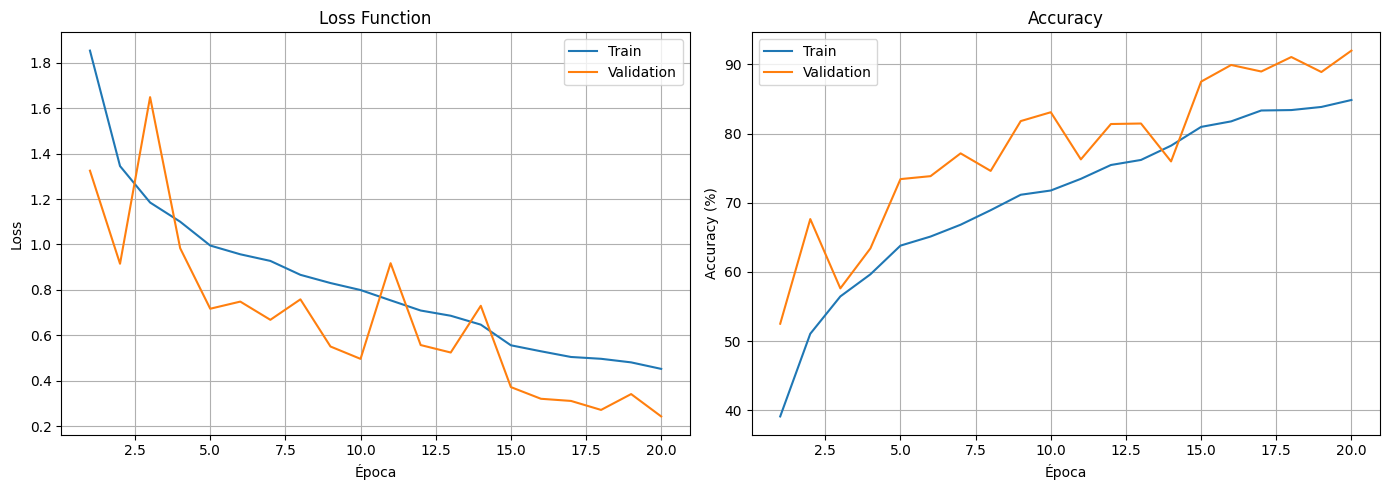

In [14]:
epocas = range(1, n_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epocas, train_losses, label='Train')
ax1.plot(epocas, val_losses,   label='Validation')
ax1.set_title('Loss Function')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epocas, train_accs, label='Train')
ax2.plot(epocas, val_accs,   label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

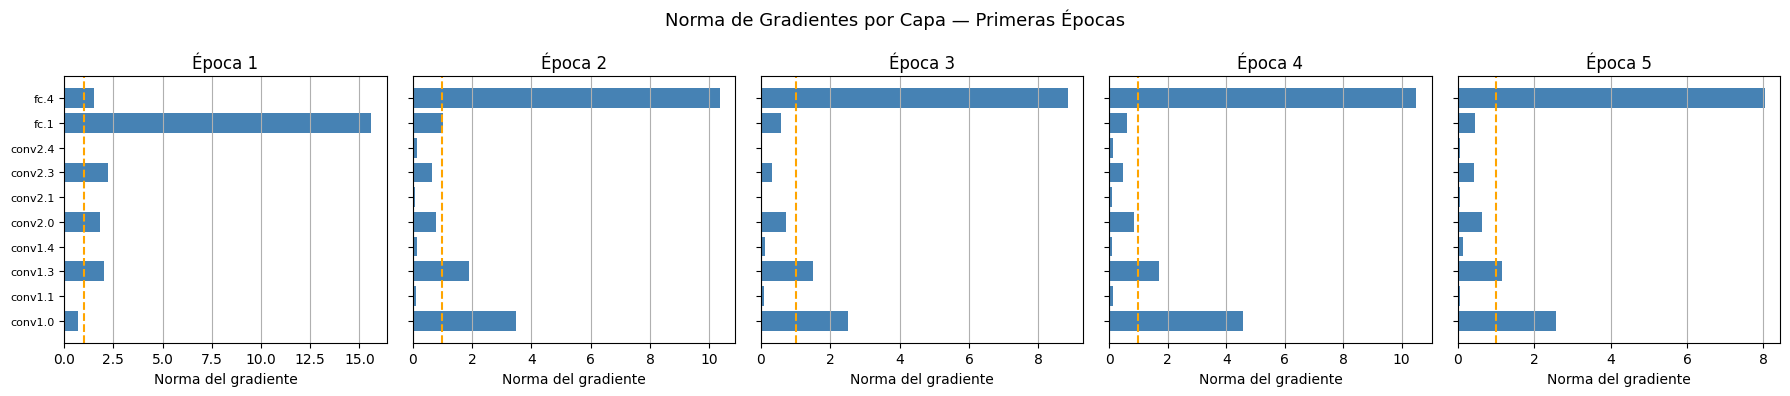

In [15]:
#Chequeo Flujo de Gradientes.

if grad_history:
    # Tomamos las capas con weights, las más representativas
    layer_names = [n for n in grad_history[0].keys() if 'weight' in n]

    fig, axes = plt.subplots(1, primeras_epochs, figsize=(18, 4), sharey=True)
    fig.suptitle('Norma de Gradientes por Capa — Primeras Épocas', fontsize=13)

    for ep, ax in enumerate(axes):
        norms = [np.mean(grad_history[ep][name]) for name in layer_names]
        ax.barh(range(len(layer_names)), norms, color='steelblue')
        ax.set_yticks(range(len(layer_names)))
        ax.set_yticklabels([n.replace('.weight', '') for n in layer_names], fontsize=8)
        ax.set_title(f'Época {ep+1}')
        ax.set_xlabel('Norma del gradiente')
        ax.axvline(x=1.0, color='orange', linestyle='--', label='ref = 1')
        ax.grid(True, axis='x')

    plt.tight_layout()
    plt.savefig('gradient_flow.png', dpi=150)
    plt.show()

### Reduccion de la Dimensionalidad

In [ ]:
model.eval()

all_features = []
all_labels   = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        feats  = model.extract_features(images)   # (batch, 256)
        all_features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

features = np.concatenate(all_features, axis=0)   # (2700, 256)
labels   = np.concatenate(all_labels,   axis=0)   # (2700,)

print('Features shape:', features.shape)

Features shape: (2700, 256)


Gráfico del espacio latente entre imágenes. 

Varianza explicada por 50 PCs: 100.0%
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2700 samples in 0.000s...
[t-SNE] Computed neighbors for 2700 samples in 4.696s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2700
[t-SNE] Computed conditional probabilities for sample 2000 / 2700
[t-SNE] Computed conditional probabilities for sample 2700 / 2700
[t-SNE] Mean sigma: 11.184906
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.771938
[t-SNE] KL divergence after 1000 iterations: 0.656238


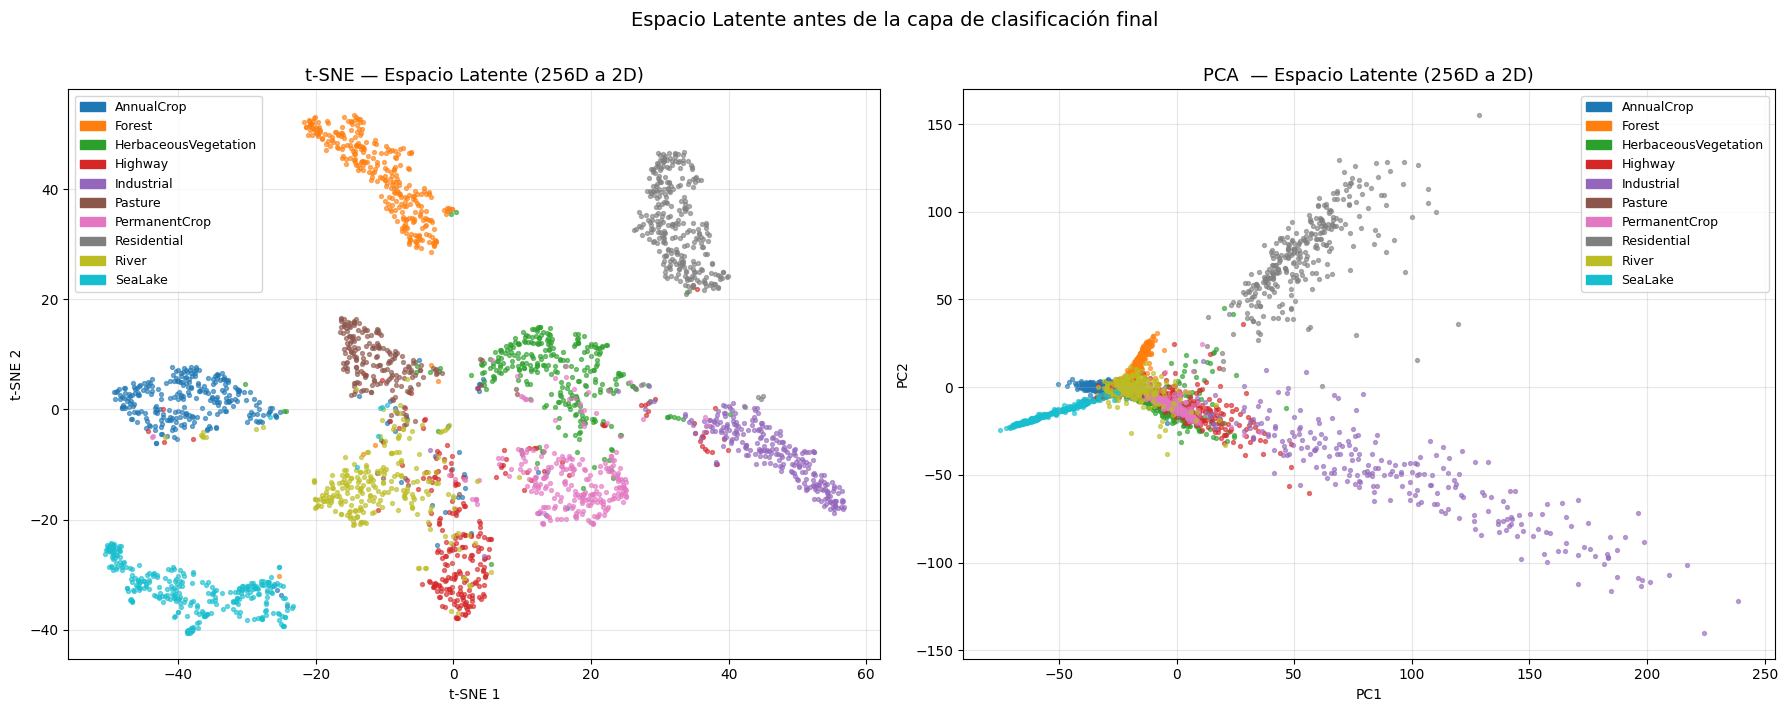

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

# Mapa de labels numéricos, nombres de clase
with open('label_map.json') as f:
    label_map = json.load(f)
    
# label_map es {nombre: número}, lo invertimos
id_to_class = {v: k for k, v in label_map.items()}
class_names = [id_to_class[i] for i in range(10)]

# PCA primero para bajar de 256 50 (acelera t-SNE) ──
pca = PCA(n_components=50, random_state=42)
features_pca50 = pca.fit_transform(features)
print(f'Varianza explicada por 50 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# t-SNE de 50 2
tsne = TSNE(n_components=2, perplexity=40,
            random_state=42, verbose=1)
features_2d = tsne.fit_transform(features_pca50)

# PCA directo a 2D (para comparar)
pca2 = PCA(n_components=2, random_state=42)
features_pca2d = pca2.fit_transform(features)

# Graficar ambos lado a lado 
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(10)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for class_id in range(10):
    mask = labels == class_id
    ax1.scatter(features_2d[mask, 0],    features_2d[mask, 1],
                color=[colors[class_id]], s=8, alpha=0.6)
    ax2.scatter(features_pca2d[mask, 0], features_pca2d[mask, 1],
                color=[colors[class_id]], s=8, alpha=0.6)

legend = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(10)]
ax1.legend(handles=legend, loc='best', fontsize=9)
ax2.legend(handles=legend, loc='best', fontsize=9)

ax1.set_title('t-SNE — Espacio Latente (256D a 2D)', fontsize=13)
ax2.set_title('PCA  — Espacio Latente (256D a 2D)',  fontsize=13)
ax1.set_xlabel('t-SNE 1'); ax1.set_ylabel('t-SNE 2')
ax2.set_xlabel('PC1');     ax2.set_ylabel('PC2')
ax1.grid(True, alpha=0.3); ax2.grid(True, alpha=0.3)

plt.suptitle('Espacio Latente antes de la capa de clasificación final', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluacion en Test

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.92      0.92       300
         Residential       0.97      1.00      0.98       300
             Pasture       0.91      0.90      0.91       300
       PermanentCrop       0.82      0.96      0.88       250
               River       0.98      0.93      0.95       250
HerbaceousVegetation       0.94      0.94      0.94       200
             SeaLake       0.94      0.82      0.87       250
              Forest       0.99      0.98      0.99       300
             Highway       0.91      0.90      0.90       250
          Industrial       0.99      0.97      0.98       300

            accuracy                           0.93      2700
           macro avg       0.93      0.93      0.93      2700
        weighted avg       0.94      0.93      0.93      2700



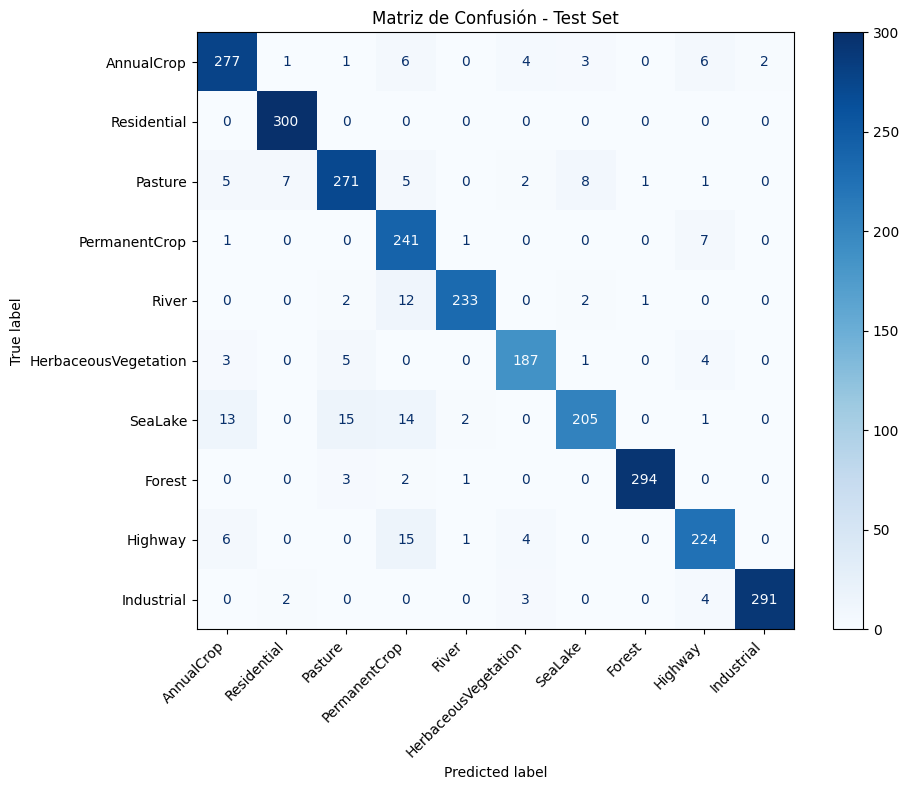

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Cargamos el mejor modelo guardado
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Nombres de las clases
class_names = df_test['ClassName'].unique()
class_names = [class_names[i] for i in sorted(df_test['Label'].unique())]

# métricas
print(classification_report(all_labels, all_preds, target_names=class_names))

# graficamos matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.title('Matriz de Confusión - Test Set')
plt.tight_layout()
plt.show()

## Transfer Learning
*Usamos la arquitectura convolucional preentrenada VGG16 para entrenar nuestro modelo*

In [17]:
# Transformaciones transfer learning 
train_transforms_tl = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG toma imagenes de 224 x 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

val_test_transforms_tl = transforms.Compose([
    transforms.Resize((224, 224)),  # 
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Datasets y loaders para transfer learning 
train_dataset_tl = EuroSATDataset(df_train, transform=train_transforms_tl)
val_dataset_tl   = EuroSATDataset(df_val,   transform=val_test_transforms_tl)
test_dataset_tl  = EuroSATDataset(df_test,  transform=val_test_transforms_tl)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=32, shuffle=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=32, shuffle=False)
test_loader_tl  = DataLoader(test_dataset_tl,  batch_size=32, shuffle=False)

In [18]:
from torchvision import models
model_transfer = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)
print(model_transfer.features)
print(model_transfer.classifier)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

### Usamos las funciones auxiliares de la Practica 17

In [19]:
from tqdm import tqdm

In [20]:
def count_trainable_params(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

def train_one_epoch(model, loader, optimizer):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


### Fine-Tuning
*Entrenamos parte de la red*

In [21]:
from torchvision import models

model_tl = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model_tl.classifier[6] = nn.Linear(4096, 10)
model_tl = model_tl.to(device)

# 1. Congelar todo
for param in model_tl.parameters():
    param.requires_grad = False

# 2. Descongelar solo features de 17 en adelante (mitad de la red masomenos).
for i, layer in enumerate(model_tl.features.children()):
    if i >= 17:
        for param in layer.parameters():
            param.requires_grad = True

# 3. Descongelar solo las últimas dos capas del clasificador
for param in model_tl.classifier[3].parameters():  # Linear(4096, 4096)
    param.requires_grad = True
for param in model_tl.classifier[6].parameters():  # Linear(4096, 10)
    param.requires_grad = True

print(f"Parámetros entrenables: {count_trainable_params(model_tl):,}")
print(f"Parámetros congelados:  {sum(p.numel() for p in model_tl.parameters() if not p.requires_grad):,}")

optimizer_tl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_tl.parameters()),
    lr=1e-4
)

tl_train_losses, tl_val_losses = [], []
tl_train_accs,   tl_val_accs   = [], []

epochs       = 10
best_val_acc_tl = 0

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_tl, train_loader_tl, optimizer_tl)
    val_loss,   val_acc   = evaluate(model_tl, val_loader_tl)

    tl_train_losses.append(train_loss)
    tl_val_losses.append(val_loss)
    tl_train_accs.append(train_acc)
    tl_val_accs.append(val_acc)

    if val_acc > best_val_acc_tl:
        best_val_acc_tl = val_acc
        torch.save(model_tl.state_dict(), 'best_model_tl.pth')
        print(f'  Mejor modelo TL guardado: {val_acc:.2f}%')

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}   | Val Acc:   {val_acc:.2f}%")

# Evaluación final sobre test, una sola vez
test_loss, test_acc = evaluate(model_tl, test_loader_tl)
print(f"\nTest Acc final: {test_acc:.2f}%")

full_finetune_acc = test_acc


Parámetros entrenables: 29,801,482
Parámetros congelados:  104,500,032


100%|██████████| 591/591 [11:43<00:00,  1.19s/it]


  Mejor modelo TL guardado: 96.30%
Train Loss: 0.3302 | Train Acc: 89.32%
Val Loss:   0.1174   | Val Acc:   96.30%


100%|██████████| 591/591 [08:41<00:00,  1.13it/s]


Train Loss: 0.1567 | Train Acc: 95.01%
Val Loss:   0.1479   | Val Acc:   94.81%


...

Train Loss: 0.0705 | Train Acc: 97.77%
Val Loss:   0.1093   | Val Acc:   96.50%


100%|██████████| 591/591 [05:30<00:00,  1.79it/s]


Train Loss: 0.0633 | Train Acc: 97.86%
Val Loss:   0.0791   | Val Acc:   97.48%


100%|██████████| 591/591 [05:32<00:00,  1.78it/s]


Train Loss: 0.0610 | Train Acc: 97.99%
Val Loss:   0.1211   | Val Acc:   96.41%

Test Acc final: 97.15%


### Evaluacion en Test - Transfer learning

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
         Residential       0.99      0.99      0.99       300
             Pasture       0.97      0.97      0.97       300
       PermanentCrop       0.97      0.96      0.97       250
               River       1.00      0.95      0.97       250
HerbaceousVegetation       0.99      0.95      0.97       200
             SeaLake       0.96      0.96      0.96       250
              Forest       0.99      1.00      0.99       300
             Highway       0.95      1.00      0.97       250
          Industrial       0.99      1.00      1.00       300

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



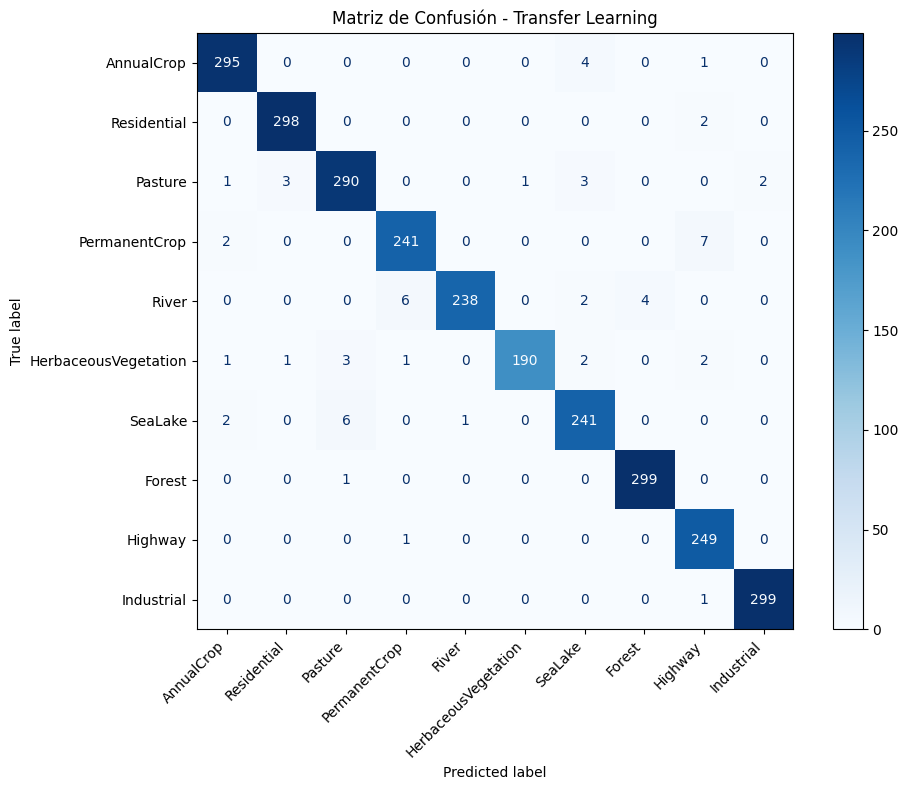

In [24]:
model_tl.load_state_dict(torch.load('best_model_tl.pth'))
model_tl.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model_tl(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.title('Matriz de Confusión - Transfer Learning')
plt.tight_layout()
plt.show()

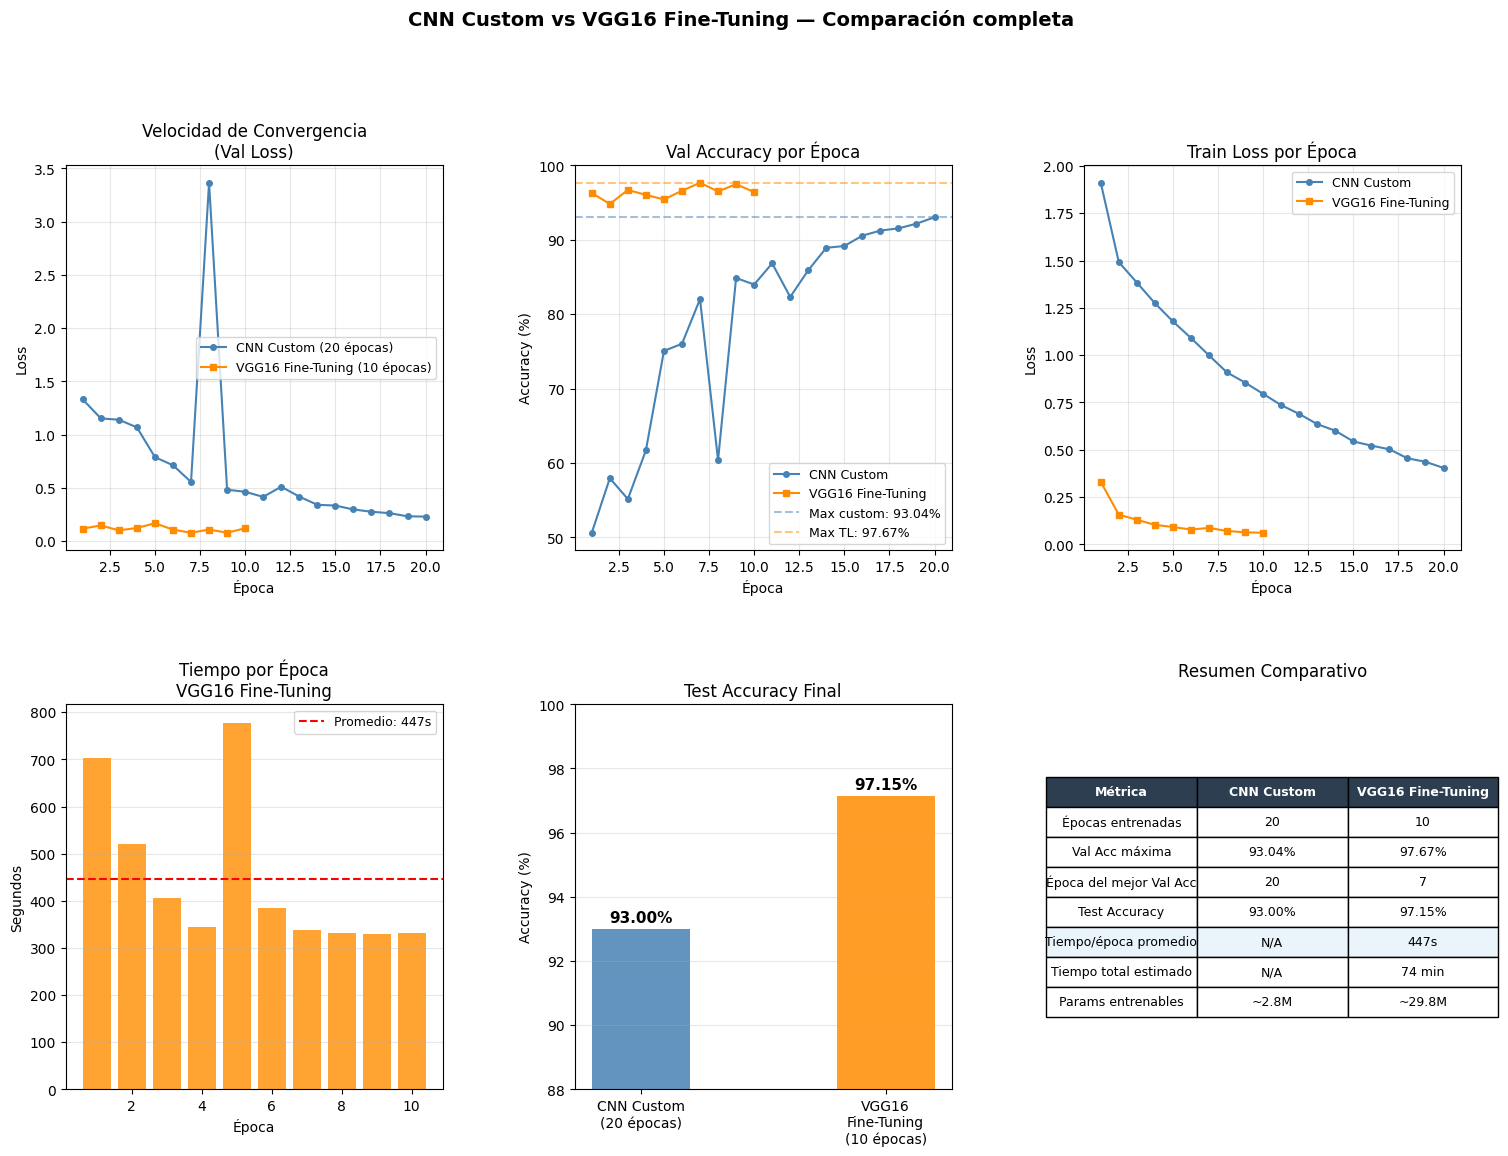

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

#  Tiempos por época de VGG16 (extraídos del output de tqdm) 
tl_epoch_times = [703, 521, 405, 344, 778, 385, 339, 331, 330, 332]

#  Métricas finales en test 
custom_test_acc = 93.0   # del classification report
tl_test_acc     = 97.15  # del print final

#  Figura principal: 3 comparaciones 
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

epochs_custom = range(1, len(train_losses) + 1)
epochs_tl     = range(1, len(tl_train_losses) + 1)

#  1. Val Loss: convergencia 
ax1.plot(epochs_custom, val_losses,    'o-', color='steelblue',  markersize=4, label='CNN Custom (20 épocas)')
ax1.plot(epochs_tl,     tl_val_losses, 's-', color='darkorange', markersize=4, label='VGG16 Fine-Tuning (10 épocas)')
ax1.set_title('Velocidad de Convergencia\n(Val Loss)', fontsize=12)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

#  2. Val Accuracy 
ax2.plot(epochs_custom, val_accs,    'o-', color='steelblue',  markersize=4, label='CNN Custom')
ax2.plot(epochs_tl,     tl_val_accs, 's-', color='darkorange', markersize=4, label='VGG16 Fine-Tuning')
ax2.axhline(y=max(val_accs),    color='steelblue',  linestyle='--', alpha=0.5, label=f'Max custom: {max(val_accs):.2f}%')
ax2.axhline(y=max(tl_val_accs), color='darkorange', linestyle='--', alpha=0.5, label=f'Max TL: {max(tl_val_accs):.2f}%')
ax2.set_title('Val Accuracy por Época', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

#  3. Train Loss 
ax3.plot(epochs_custom, train_losses,    'o-', color='steelblue',  markersize=4, label='CNN Custom')
ax3.plot(epochs_tl,     tl_train_losses, 's-', color='darkorange', markersize=4, label='VGG16 Fine-Tuning')
ax3.set_title('Train Loss por Época', fontsize=12)
ax3.set_xlabel('Época')
ax3.set_ylabel('Loss')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

#  4. Tiempo por época (TL) 
ax4.bar(range(1, 11), tl_epoch_times, color='darkorange', alpha=0.8)
ax4.axhline(y=np.mean(tl_epoch_times), color='red', linestyle='--',
            label=f'Promedio: {np.mean(tl_epoch_times):.0f}s')
ax4.set_title('Tiempo por Época\nVGG16 Fine-Tuning', fontsize=12)
ax4.set_xlabel('Época')
ax4.set_ylabel('Segundos')
ax4.legend(fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)

#  5. Test Accuracy final 
modelos = ['CNN Custom\n(20 épocas)', 'VGG16\nFine-Tuning\n(10 épocas)']
accs    = [custom_test_acc, tl_test_acc]
bars    = ax5.bar(modelos, accs, color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
ax5.set_ylim(88, 100)
ax5.set_title('Test Accuracy Final', fontsize=12)
ax5.set_ylabel('Accuracy (%)')
for bar, acc in zip(bars, accs):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax5.grid(True, axis='y', alpha=0.3)

#  6. Tabla resumen 
ax6.axis('off')
tabla_data = [
    ['Métrica',                  'CNN Custom',              'VGG16 Fine-Tuning'],
    ['Épocas entrenadas',        '20',                      '10'],
    ['Val Acc máxima',           f'{max(val_accs):.2f}%',   f'{max(tl_val_accs):.2f}%'],
    ['Época del mejor Val Acc',  str(val_accs.index(max(val_accs))+1),
                                                            str(tl_val_accs.index(max(tl_val_accs))+1)],
    ['Test Accuracy',            f'{custom_test_acc:.2f}%', f'{tl_test_acc:.2f}%'],
    ['Tiempo/época promedio',    'N/A',                     f'{np.mean(tl_epoch_times):.0f}s'],
    ['Tiempo total estimado',    'N/A',                     f'{sum(tl_epoch_times)//60:.0f} min'],
    ['Params entrenables',       '~2.8M',                   '~29.8M'],
]
tabla = ax6.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                  loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.8)

# Header con color
for j in range(3):
    tabla[0, j].set_facecolor('#2c3e50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
# Fila de test accuracy resaltada
for j in range(3):
    tabla[5, j].set_facecolor('#eaf4fb')

ax6.set_title('Resumen Comparativo', fontsize=12, pad=20)

fig.suptitle('CNN Custom vs VGG16 Fine-Tuning — Comparación completa',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()